# Model KNN untuk Prediksi Kelulusan Mata Kuliah AI

Notebook ini berisi implementasi algoritma K-Nearest Neighbors (KNN) untuk memprediksi kelulusan mata kuliah AI, beserta evaluasi menggunakan confusion matrix, accuracy, precision, dan recall.

## 1. Import Library

In [6]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score

## 2. Load Dataset

In [7]:
# Load data training dan testing
df_train = pd.read_excel('../data/kelulusan_train.xls')
df_test = pd.read_excel('../data/kelulusan_test.xls')

print("Data Training:")
print(df_train.head())
print(f"\nShape: {df_train.shape}")

print("\n" + "="*50)
print("\nData Testing:")
print(df_test.head())
print(f"\nShape: {df_test.shape}")

Data Training:
                      NAMA JENIS KELAMIN STATUS MAHASISWA  UMUR  \
0           ANIK WIDAYANTI     PEREMPUAN          BEKERJA    28   
1  DWI HESTYNA PRIHASTANTY     PEREMPUAN        MAHASISWA    32   
2       MURYA ARIEF BASUKI     PEREMPUAN          BEKERJA    29   
3            NANIK SUSANTI     PEREMPUAN        MAHASISWA    27   
4        RIFKA ISTIQFARINA     PEREMPUAN          BEKERJA    29   

    STATUS NIKAH  IPS 1  IPS 2  IPS 3  IPS 4  IPS 5  IPS 6  IPS 7  IPS 8  \
0  BELUM MENIKAH   2.76   2.80   3.20   3.17   2.98   3.00   3.03    0.0   
1  BELUM MENIKAH   3.00   3.30   3.14   3.14   2.84   3.13   3.25    0.0   
2  BELUM MENIKAH   3.50   3.30   3.70   3.29   3.53   3.72   3.73    0.0   
3  BELUM MENIKAH   3.17   3.41   3.61   3.36   3.48   3.63   3.46    0.0   
4  BELUM MENIKAH   2.90   2.89   3.30   2.85   2.98   3.00   3.08    0.0   

   IPK  STATUS KELULUSAN  
0  3.07        TERLAMBAT  
1  3.17        TERLAMBAT  
2  3.54        TERLAMBAT  
3  3.41        TE

## 3. Data Preprocessing

In [8]:
# Drop kolom STATUS NIKAH karena tidak relevan
df_train.drop(columns=['STATUS NIKAH'], inplace=True)
df_test.drop(columns=['STATUS NIKAH'], inplace=True)

# Encoding data kategorikal
replacements = {
    'JENIS KELAMIN': {'LAKI - LAKI': 1, 'PEREMPUAN': 0},
    'STATUS MAHASISWA': {'MAHASISWA': 0, 'BEKERJA': 1},
    'STATUS KELULUSAN': {'TERLAMBAT': 1, 'TEPAT': 0}
}

df_train = df_train.replace(replacements, inplace=False)
df_test = df_test.replace(replacements, inplace=False)

print("Data setelah encoding:")
print(df_train.head())

Data setelah encoding:
                      NAMA  JENIS KELAMIN  STATUS MAHASISWA  UMUR  IPS 1  \
0           ANIK WIDAYANTI              0                 1    28   2.76   
1  DWI HESTYNA PRIHASTANTY              0                 0    32   3.00   
2       MURYA ARIEF BASUKI              0                 1    29   3.50   
3            NANIK SUSANTI              0                 0    27   3.17   
4        RIFKA ISTIQFARINA              0                 1    29   2.90   

   IPS 2  IPS 3  IPS 4  IPS 5  IPS 6  IPS 7  IPS 8  IPK   STATUS KELULUSAN  
0   2.80   3.20   3.17   2.98   3.00   3.03    0.0  3.07                 1  
1   3.30   3.14   3.14   2.84   3.13   3.25    0.0  3.17                 1  
2   3.30   3.70   3.29   3.53   3.72   3.73    0.0  3.54                 1  
3   3.41   3.61   3.36   3.48   3.63   3.46    0.0  3.41                 1  
4   2.89   3.30   2.85   2.98   3.00   3.08    0.0  3.09                 1  


C:\Users\nuril\AppData\Local\Temp\ipykernel_15196\4150532485.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train = df_train.replace(replacements, inplace=False)
C:\Users\nuril\AppData\Local\Temp\ipykernel_15196\4150532485.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test = df_test.replace(replacements, inplace=False)


In [9]:
# Cek missing values
print("Missing values pada data training:")
print(df_train.isnull().sum())

print("\n" + "="*50)
print("\nMissing values pada data testing:")
print(df_test.isnull().sum())

Missing values pada data training:
NAMA                0
JENIS KELAMIN       0
STATUS MAHASISWA    0
UMUR                0
IPS 1               0
IPS 2               0
IPS 3               0
IPS 4               0
IPS 5               0
IPS 6               0
IPS 7               0
IPS 8               7
IPK                 3
STATUS KELULUSAN    0
dtype: int64


Missing values pada data testing:
NAMA                0
JENIS KELAMIN       0
STATUS MAHASISWA    0
UMUR                0
IPS 1               0
IPS 2               0
IPS 3               0
IPS 4               0
IPS 5               0
IPS 6               0
IPS 7               0
IPS 8               4
IPK                 3
STATUS KELULUSAN    0
dtype: int64


In [10]:
# Hapus missing values
df_train = df_train.dropna(subset=['IPS 8'])
df_train = df_train.dropna(subset=['IPK '])

df_test = df_test.dropna(subset=['IPS 8'])
df_test = df_test.dropna(subset=['IPK '])

# Drop kolom NAMA
df_train = df_train.drop(columns=['NAMA'])
df_test = df_test.drop(columns=['NAMA'])

print("Data setelah preprocessing:")
print(f"Training shape: {df_train.shape}")
print(f"Testing shape: {df_test.shape}")

Data setelah preprocessing:
Training shape: (369, 13)
Testing shape: (138, 13)


## 4. Split Features dan Target

In [11]:
# Pisahkan features (X) dan target (y)
X_train = df_train.drop(columns=['STATUS KELULUSAN'])
y_train = df_train['STATUS KELULUSAN']

X_test = df_test.drop(columns=['STATUS KELULUSAN'])
y_test = df_test['STATUS KELULUSAN']

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (369, 12)
y_train shape: (369,)
X_test shape: (138, 12)
y_test shape: (138,)


## 5. Normalisasi Data

In [12]:
# Normalisasi features menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data telah dinormalisasi")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Data telah dinormalisasi
X_train_scaled shape: (369, 12)
X_test_scaled shape: (138, 12)


## 6. Membuat Model KNN

In [13]:
# Membuat model KNN dengan k=5 (nilai default yang sering digunakan)
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

# Training model
knn_model.fit(X_train_scaled, y_train)

print("Model KNN berhasil dibuat dan dilatih!")
print(f"Parameter model: k={knn_model.n_neighbors}, metric={knn_model.metric}")

Model KNN berhasil dibuat dan dilatih!
Parameter model: k=5, metric=euclidean


## 7. Prediksi dan Evaluasi Model

In [14]:
# Melakukan prediksi pada data test
y_pred = knn_model.predict(X_test_scaled)

print("Prediksi berhasil dilakukan!")
print(f"\nContoh 10 hasil prediksi pertama:")
print(y_pred[:10])
print(f"\nNilai aktual:")
print(y_test.values[:10])

Prediksi berhasil dilakukan!

Contoh 10 hasil prediksi pertama:
[0 1 0 0 0 0 0 0 0 0]

Nilai aktual:
[0 0 0 0 0 0 0 0 0 0]


## 8. Confusion Matrix

In [15]:
# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Membuat DataFrame untuk tampilan yang lebih baik
cm_df = pd.DataFrame(cm, 
                     index=['Actual: Tepat (0)', 'Actual: Terlambat (1)'],
                     columns=['Predicted: Tepat (0)', 'Predicted: Terlambat (1)'])

print("Confusion Matrix:")
print("="*60)
print(cm_df)
print("\n")

# Ekstrak nilai dari confusion matrix
TN = cm[0, 0]  # True Negative
FP = cm[0, 1]  # False Positive
FN = cm[1, 0]  # False Negative
TP = cm[1, 1]  # True Positive

print(f"True Negative (TN): {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"True Positive (TP): {TP}")

Confusion Matrix:
                       Predicted: Tepat (0)  Predicted: Terlambat (1)
Actual: Tepat (0)                       129                         7
Actual: Terlambat (1)                     1                         1


True Negative (TN): 129
False Positive (FP): 7
False Negative (FN): 1
True Positive (TP): 1


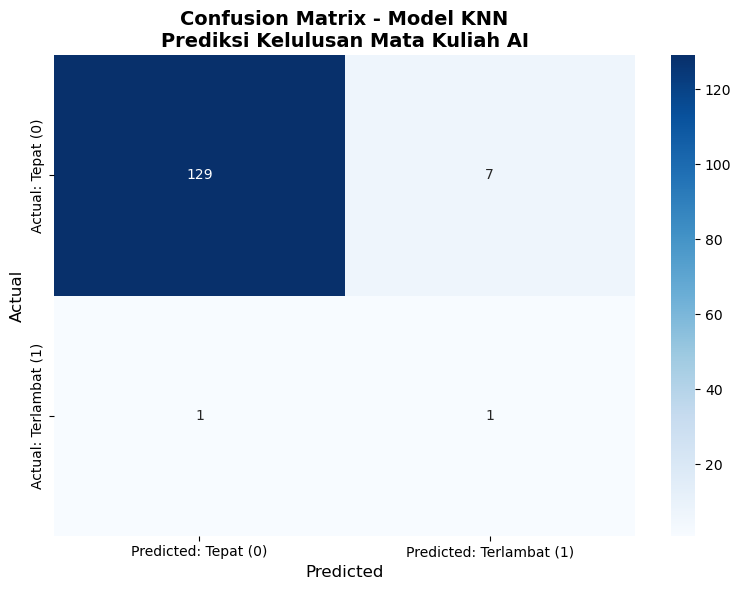

In [16]:
# Visualisasi Confusion Matrix dengan heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=['Predicted: Tepat (0)', 'Predicted: Terlambat (1)'],
            yticklabels=['Actual: Tepat (0)', 'Actual: Terlambat (1)'])
plt.title('Confusion Matrix - Model KNN\nPrediksi Kelulusan Mata Kuliah AI', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Perhitungan Metrik Evaluasi (Accuracy, Precision, Recall)

In [17]:
# Menghitung metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')
recall = recall_score(y_test, y_pred, average='binary')

# Konversi ke persentase
accuracy_pct = accuracy * 100
precision_pct = precision * 100
recall_pct = recall * 100

print("="*60)
print("METRIK EVALUASI MODEL KNN")
print("="*60)
print(f"Accuracy  : {accuracy:.4f} = {accuracy_pct:.2f}%")
print(f"Precision : {precision:.4f} = {precision_pct:.2f}%")
print(f"Recall    : {recall:.4f} = {recall_pct:.2f}%")
print("="*60)

METRIK EVALUASI MODEL KNN
Accuracy  : 0.9420 = 94.20%
Precision : 0.1250 = 12.50%
Recall    : 0.5000 = 50.00%


In [18]:
# Membuat tabel ringkasan metrik evaluasi
metrics_data = {
    'Metrik': ['Accuracy', 'Precision', 'Recall'],
    'Nilai Desimal': [f'{accuracy:.4f}', f'{precision:.4f}', f'{recall:.4f}'],
    'Persentase': [f'{accuracy_pct:.2f}%', f'{precision_pct:.2f}%', f'{recall_pct:.2f}%']
}

metrics_df = pd.DataFrame(metrics_data)

print("\nTABEL RINGKASAN METRIK EVALUASI")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)


TABEL RINGKASAN METRIK EVALUASI
   Metrik Nilai Desimal Persentase
 Accuracy        0.9420     94.20%
Precision        0.1250     12.50%
   Recall        0.5000     50.00%


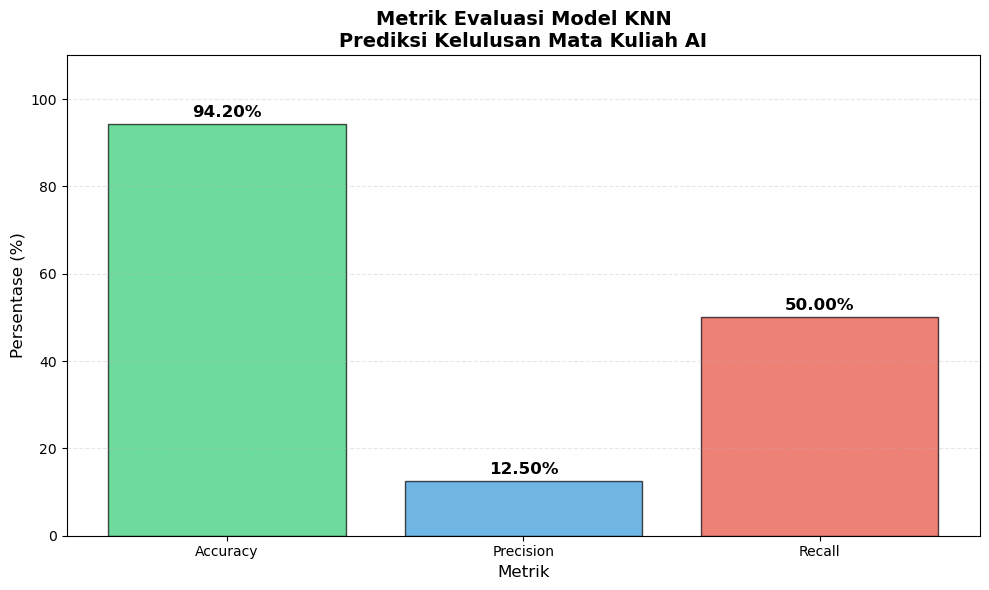

In [19]:
# Visualisasi metrik evaluasi dengan bar chart
plt.figure(figsize=(10, 6))
metrics_names = ['Accuracy', 'Precision', 'Recall']
metrics_values = [accuracy_pct, precision_pct, recall_pct]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = plt.bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')

# Menambahkan nilai di atas setiap bar
for i, (bar, value) in enumerate(zip(bars, metrics_values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{value:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Metrik Evaluasi Model KNN\nPrediksi Kelulusan Mata Kuliah AI', fontsize=14, fontweight='bold')
plt.ylabel('Persentase (%)', fontsize=12)
plt.xlabel('Metrik', fontsize=12)
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 10. Classification Report (Detail)

In [20]:
# Menampilkan classification report lengkap
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Tepat (0)', 'Terlambat (1)']))
print("="*60)

CLASSIFICATION REPORT
               precision    recall  f1-score   support

    Tepat (0)       0.99      0.95      0.97       136
Terlambat (1)       0.12      0.50      0.20         2

     accuracy                           0.94       138
    macro avg       0.56      0.72      0.58       138
 weighted avg       0.98      0.94      0.96       138



## Kesimpulan

Model KNN telah berhasil dibuat untuk prediksi kelulusan mata kuliah AI dengan hasil sebagai berikut:

### Interpretasi Metrik:
- **Accuracy**: Persentase prediksi yang benar dari total prediksi
- **Precision**: Dari semua prediksi positif (Terlambat), berapa persen yang benar
- **Recall**: Dari semua yang sebenarnya positif (Terlambat), berapa persen yang berhasil diprediksi

### Confusion Matrix:
- **True Negative (TN)**: Prediksi Tepat, Aktual Tepat (Benar)
- **False Positive (FP)**: Prediksi Terlambat, Aktual Tepat (Salah)
- **False Negative (FN)**: Prediksi Tepat, Aktual Terlambat (Salah)
- **True Positive (TP)**: Prediksi Terlambat, Aktual Terlambat (Benar)